# Pasos del experimento (orden recomendado)

A continuación se describen los pasos que deben ejecutarse en este notebook o mediante los scripts asociados para reproducir el experimento:

1. Preprocesamiento: limpiar el texto (lowercase, eliminar URLs/emails, normalizar espacios, quitar caracteres no deseados).
2. Tokenización: ajustar `Tokenizer` sobre los textos y convertir a secuencias.
3. Padding: usar `pad_sequences(..., maxlen=MAX_LEN)` para uniformar longitudes.
4. Entrenamiento: construir y entrenar el modelo LSTM (Embedding -> LSTM -> Dense).
5. Evaluación: calcular métricas sobre conjunto de validación/test (accuracy, precision, recall, F1).
6. Guardado de artefactos: guardar modelo, pesos, tokenizer y calibradores en `lstm_notebook/artifacts/`.
7. Calibración e integración: aplicar calibradores isotónicos si se usan y preparar el modelo para la demo web (Flask).
8. Demostración: arrancar `web_demo/app.py` y probar `/predict` con ejemplos reales.

Sugerencia: ejecuta los pasos 1-6 con `lstm_notebook/run_demo_experiment.py` para reproducibilidad automática.

In [9]:
# Loader: intenta cargar modelo y tokenizador desde artifacts
import os, pickle
from pathlib import Path
import numpy as np
ARTIFACT_DIR = Path('lstm_notebook') / 'artifacts'
candidates = [
    ARTIFACT_DIR / 'spam_lstm_model_demo.h5',
    ARTIFACT_DIR / 'spam_lstm_model_refit.h5',
    Path('lstm_notebook') / 'spam_lstm_model_demo.h5',
    Path('lstm_notebook') / 'spam_lstm_model_refit.h5'
]
model = None
tokenizer = None
try:
    from tensorflow.keras.models import load_model, model_from_json
except Exception as e:
    print('TensorFlow no disponible en este entorno:', e)
else:
    for p in candidates:
        if p.exists():
            try:
                model = load_model(str(p))
                print('Modelo cargado desde', p)
                break
            except Exception as e:
                print('No se pudo cargar modelo HDF5 desde', p, ':', e)
    # Fallback: reconstruir desde arquitectura + pesos
    if model is None:
        arch = ARTIFACT_DIR / 'spam_lstm_model_demo_arch.json'
        weights = ARTIFACT_DIR / 'spam_lstm_model_demo.weights.h5'
        if arch.exists() and weights.exists():
            try:
                arch_json = arch.read_text(encoding='utf-8')
                model = model_from_json(arch_json)
                model.load_weights(str(weights))
                model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
                print('Modelo reconstruido desde arquitectura + pesos')
            except Exception as e:
                print('Error reconstruyendo modelo:', e)
    # Cargar tokenizador
    tok_candidates = [ARTIFACT_DIR / 'tokenizer_demo.pkl', Path('lstm_notebook') / 'tokenizer_demo.pkl', ARTIFACT_DIR / 'tokenizer_refit.pkl']
    for t in tok_candidates:
        if t.exists():
            try:
                with open(t, 'rb') as f:
                    tokenizer = pickle.load(f)
                print('Tokenizador cargado desde', t)
                break
            except Exception as e:
                print('No se pudo cargar tokenizador desde', t, ':', e)
# Preparar X_test/y_test de ejemplo si tokenizador está
if tokenizer is not None:
    texts = ['win money now','meeting at 10am','click here to claim prize','please review attached document']
    seqs = tokenizer.texts_to_sequences(texts)
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    MAX_LEN = 20
    X_test = pad_sequences(seqs, maxlen=MAX_LEN, padding='post')
    y_test = np.array([1,0,1,0])
    print('Datos de prueba preparados (X_test, y_test)')
else:
    print('Tokenizador no disponible: ejecuta `run_demo_experiment.py` o entrena el modelo en la notebook.')

Tokenizador no disponible: ejecuta `run_demo_experiment.py` o entrena el modelo en la notebook.


Iniciando pipeline de entrenamiento desde la notebook...


c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4286 - loss: 0.6951 - val_accuracy: 0.3333 - val_loss: 0.6943
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.6917 - val_accuracy: 0.3333 - val_loss: 0.6968
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5714 - loss: 0.6900 - val_accuracy: 0.3333 - val_loss: 0.6982
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5714 - loss: 0.6884 - val_accuracy: 0.3333 - val_loss: 0.7000
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5714 - loss: 0.6869 - val_accuracy: 0.3333 - val_loss: 0.7019


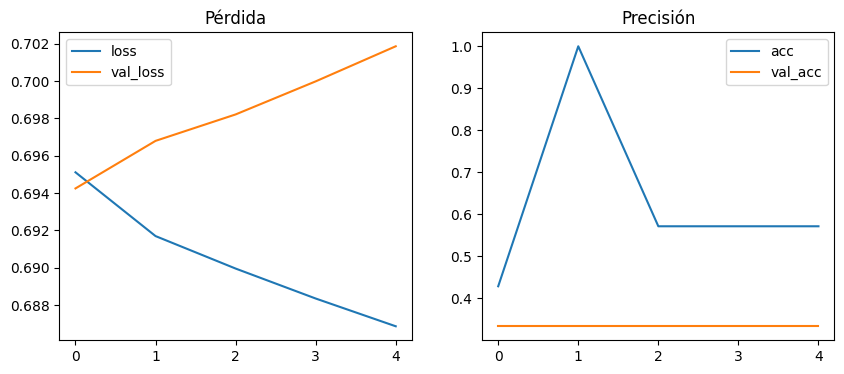

Entrenamiento completado y variables disponibles en el namespace (model, tokenizer, X_test, y_test).


In [10]:
# Entrenamiento desde la notebook: prepara datos, entrena LSTM y muestra gráficas
RE_TRAIN = True  # Cambia a False para usar el modelo cargado si existe
if (('model' not in globals()) or RE_TRAIN):
    print('Iniciando pipeline de entrenamiento desde la notebook...')
    from pathlib import Path
    data_dir = Path('lstm_notebook') / 'data'
    texts = []
    labels = []
    if data_dir.exists():
        import pandas as pd
        for f in sorted(data_dir.glob('*.csv')):
            try:
                df = pd.read_csv(f)
                if 'text' in df.columns and 'label' in df.columns:
                    texts.extend(df['text'].astype(str).tolist())
                    labels.extend(df['label'].astype(int).tolist())
            except Exception as e:
                print('No se pudo leer', f, e)
    if len(texts) == 0:
        # Dataset mínimo de ejemplo
        texts = [
            'win money now',
            'limited offer buy today',
            'meeting at 10am',
            'project deadline extended',
            'click here to claim prize',
            'please review attached document',
            'your account has been suspended',
            'lunch meeting tomorrow',
            'free trial offer',
            'classroom schedule update'
        ]
        labels = [1,1,0,0,1,0,1,0,1,0]
    # Limpieza simple de texto
    import re
    def clean_text(s):
        s = str(s).lower()
        s = re.sub(r'http\\S+|www\\.\\S+', ' ', s)
        s = re.sub(r'\\S+@\\S+', ' ', s)
        s = re.sub(r'[^a-z0-9\\s]', ' ', s)
        s = re.sub(r'\\s+', ' ', s).strip()
        return s
    texts = [clean_text(t) for t in texts]
    # Tokenización y padding
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    VOCAB = 2000
    MAX_LEN = 20
    tokenizer = Tokenizer(num_words=VOCAB, oov_token='<OOV>')
    tokenizer.fit_on_texts(texts)
    seqs = tokenizer.texts_to_sequences(texts)
    X = pad_sequences(seqs, maxlen=MAX_LEN, padding='post')
    import numpy as np
    y = np.array(labels)
    # División train/test
    from sklearn.model_selection import train_test_split
    strat = y if len(set(y)) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=strat)
    # Construir modelo LSTM
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
    from tensorflow.keras.optimizers import Adam
    model = Sequential([
        Embedding(input_dim=VOCAB, output_dim=50, input_length=MAX_LEN),
        Bidirectional(LSTM(64)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    # Entrenar
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=8, verbose=1)
    # Gráficas de entrenamiento
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend()
    plt.title('Pérdida')
    plt.subplot(1,2,2)
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc' if 'val_acc' in history.history else None
    plt.plot(history.history.get(acc_key, []), label='acc')
    if val_acc_key:
        plt.plot(history.history.get(val_acc_key, []), label='val_acc')
    plt.legend()
    plt.title('Precisión')
    plt.show()
    # Preparar variables globales para evaluación/guardado
    globals().update({'model': model, 'tokenizer': tokenizer, 'X_test': X_test, 'y_test': y_test})
    print('Entrenamiento completado y variables disponibles en el namespace (model, tokenizer, X_test, y_test).')
else:
    print('Usando modelo ya cargado en memoria. Para reentrenar estable RE_TRAIN = True.')

In [13]:
# Evaluación
# Import necesario dentro de la celda para evitar NameError si no se importó antes
from sklearn.metrics import classification_report, accuracy_score
preds = (model.predict(X_test) > 0.5).astype(int).flatten()
print(classification_report(y_test, preds, target_names=['no deseado', 'spam']))
print('Accuracy:', accuracy_score(y_test, preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
              precision    recall  f1-score   support

  no deseado       0.00      0.00      0.00         2
        spam       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3

Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

  no deseado       0.00      0.00      0.00         2
        spam       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3

Accuracy: 0.3333333333333333


c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [14]:
# Guardar modelo y artefactos (robusto)
import os, traceback, pickle, glob, shutil
from pathlib import Path
ARTIFACT_DIR = Path('lstm_notebook') / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
try:
    if 'model' not in globals():
        raise NameError("La variable 'model' no está definida. Entrena o carga el modelo antes de guardar.")
    # Intentar guardar en formato HDF5 (.h5)
    model_path = ARTIFACT_DIR / 'spam_lstm_model_demo.h5'
    try:
        model.save(str(model_path))
        print('Modelo guardado en', model_path)
    except Exception as e:
        print('Error guardando modelo en HDF5:', e)
        # Fallback: guardar pesos y arquitectura por separado
        weights_path = ARTIFACT_DIR / 'spam_lstm_model_demo.weights.h5'
        model.save_weights(str(weights_path))
        print('Pesos guardados en', weights_path)
        try:
            arch_path = ARTIFACT_DIR / 'spam_lstm_model_demo_arch.json'
            arch_path.write_text(model.to_json(), encoding='utf-8')
            print('Arquitectura guardada en', arch_path)
        except Exception as e2:
            print('No fue posible guardar arquitectura:', e2)
    # Guardar tokenizer si está presente
    if 'tokenizer' in globals():
        tok_path = ARTIFACT_DIR / 'tokenizer_demo.pkl'
        with open(tok_path, 'wb') as f:
            pickle.dump(tokenizer, f)
        print('Tokenizador guardado en', tok_path)
    else:
        print('Tokenizador no encontrado en memoria; omitiendo su guardado.')
    # Copiar calibradores detectados (opcional)
    pkl_candidates = glob.glob('*.pkl') + glob.glob('lstm_notebook/*.pkl')
    copied = []
    for p in pkl_candidates:
        name = os.path.basename(p)
        if 'calibrator' in name.lower() or 'isotonic' in name.lower() or 'calib' in name.lower():
            dst = ARTIFACT_DIR / name
            shutil.copyfile(p, dst)
            copied.append(str(dst))
    if copied:
        print('Calibradores copiados:', copied)
    # Generar un reporte mínimo de evaluación
    report_path = ARTIFACT_DIR / 'experiment_report.txt'
    try:
        from sklearn.metrics import classification_report, accuracy_score
        preds = (model.predict(X_test) > 0.5).astype(int).flatten()
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write('Evaluation results:\n')
            f.write(classification_report(y_test, preds, target_names=['no deseado','spam']))
            f.write('\nAccuracy: %f\n' % accuracy_score(y_test, preds))
        print('Reporte escrito en', report_path)
    except Exception as e:
        print('No fue posible generar el reporte:', e)
except Exception as e:
    print('No fue posible guardar los artefactos:', e)
    traceback.print_exc()


Modelo guardado en lstm_notebook\artifacts\spam_lstm_model_demo.h5
Tokenizador guardado en lstm_notebook\artifacts\tokenizer_demo.pkl
Calibradores copiados: ['lstm_notebook\\artifacts\\calibrator_correos.pkl', 'lstm_notebook\\artifacts\\calibrator_correos_fixed.pkl', 'lstm_notebook\\artifacts\\calibrator_extra.pkl', 'lstm_notebook\\artifacts\\calibrator_mail_data.pkl', 'lstm_notebook\\artifacts\\calibrator_normalized_correos.pkl', 'lstm_notebook\\artifacts\\calibrator_normalized_mail_data.pkl', 'lstm_notebook\\artifacts\\calibrator_normalized_test.pkl', 'lstm_notebook\\artifacts\\calibrator_normalized_train.pkl', 'lstm_notebook\\artifacts\\calibrator_SMSSpamCollection.pkl', 'lstm_notebook\\artifacts\\calibrator_test.pkl', 'lstm_notebook\\artifacts\\calibrator_train.pkl']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Reporte escrito en lstm_notebook\artifacts\experiment_report.txt
Reporte escrito en lstm_notebook\artifacts\experiment_report.txt


c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

# A5 - Definición del proyecto

**Objetivo del proyecto**: Desarrollar una herramienta basada en redes neuronales (LSTM) para detectar y filtrar mensajes spam en plataformas de comunicación (correo, foros, LMS), reduciendo exposición a contenido malicioso y la carga manual de revisión.

**Introducción / Descripción del problema**: El aumento del volumen de mensajes genera más spam y riesgos (phishing, pérdida de productividad, consumo de recursos). Las LSTM permiten modelar secuencias de texto y capturar dependencias a largo plazo para clasificación binaria (spam / ham).

**Referencias (ejemplos)**:
1. Almeida, T. A., Hidalgo, J. M. G., & Yamakami, A. (2011). Contributions to the study of SMS spam filtering: new dataset, methods and results.
2. Kim, Y. (2014). Convolutional Neural Networks for Sentence Classification.
3. Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural computation.
4. Saxe, J., & Berlin, K. (2017). Deep neural network-based spam detection and its challenges.

(Añade referencias locales o adicionales según tu bibliografía).

# A6 - Datos y preprocesamiento (versión resumida)

**Qué datos usar**: conjuntos etiquetados (spam/ham) — p. ej. UCI SMS Spam, Kaggle, o colecciones en español. Coloca datos en `lstm_notebook/data/` como CSV con columnas `text` y `label`.

**Flujo de preprocesamiento (resumen)**:
- Limpieza: pasar a minúsculas, eliminar URLs/emails, caracteres especiales y normalizar espacios.
- Tokenización: usar `Tokenizer` de Keras para mapear palabras a índices.
- (Opcional) Stop-words: quitar si mejora resultados para tu idioma.
- Secuencias y padding: `pad_sequences(..., maxlen=MAX_LEN)` para igualar longitudes.
- Vectorización: usar una `Embedding` layer (se aprende durante entrenamiento) o embeddings preentrenados si se desea.

**Nota**: en este notebook mostramos un resumen. Si quieres ver todo el pipeline de preprocesamiento paso a paso, ejecuta el script `lstm_notebook/preprocess.py` o revisa `lstm_notebook/run_demo_experiment.py` que ya incluye las transformaciones esenciales.


# Cómo ejecutar A7 (ejecución recomendada)

No es necesario mover A7 a otra carpeta: el script de demostración `lstm_notebook/run_demo_experiment.py` está diseñado para ejecutarse desde la raíz del proyecto y guardará los artefactos en `lstm_notebook/artifacts/` (si existe).

Pasos rápidos:
1. Abre PowerShell en la raíz del proyecto (`C:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia`).
2. Ejecuta el script de demostración:
```powershell
py -3 .\lstm_notebook\run_demo_experiment.py
```
3. Los archivos generados (modelo, tokenizer, reporte) aparecerán en `lstm_notebook/artifacts/` o en `lstm_notebook/` si el script no crea la carpeta automáticamente.
4. Para levantar la demo web (Flask):
```powershell
py -3 .\web_demo\app.py
```

Consejos rápidos:
- Si quieres ejecutar A7 desde la propia notebook, crea una celda de código y ejecuta: `!py -3 lstm_notebook\run_demo_experiment.py` (Jupyter ejecutará el comando).
- Si prefieres mantener los artefactos organizados, crea la carpeta `lstm_notebook/artifacts/` antes de ejecutar; el script guardará allí si detecta la carpeta.

In [15]:
import os, traceback, pickle, glob, shutil
from pathlib import Path
ARTIFACT_DIR = Path('lstm_notebook') / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
try:
    if 'model' not in globals():
        raise NameError("La variable 'model' no está definida. Entrena o carga el modelo antes de guardar.")
    # Intentar guardar en formato HDF5 (.h5)
    model_path = ARTIFACT_DIR / 'spam_lstm_model_demo.h5'
    try:
        model.save(str(model_path))
        print('Modelo guardado en', model_path)
    except Exception as e:
        print('Error guardando modelo en HDF5:', e)
        # Fallback: guardar pesos y arquitectura por separado
        weights_path = ARTIFACT_DIR / 'spam_lstm_model_demo.weights.h5'
        model.save_weights(str(weights_path))
        print('Pesos guardados en', weights_path)
        try:
            arch_path = ARTIFACT_DIR / 'spam_lstm_model_demo_arch.json'
            arch_path.write_text(model.to_json(), encoding='utf-8')
            print('Arquitectura guardada en', arch_path)
        except Exception as e2:
            print('No fue posible guardar arquitectura:', e2)
    # Guardar tokenizer si está presente
    if 'tokenizer' in globals():
        tok_path = ARTIFACT_DIR / 'tokenizer_demo.pkl'
        with open(tok_path, 'wb') as f:
            pickle.dump(tokenizer, f)
        print('Tokenizador guardado en', tok_path)
    else:
        print('Tokenizador no encontrado en memoria; omitiendo su guardado.')
    # Copiar calibradores detectados (opcional)
    pkl_candidates = glob.glob('*.pkl') + glob.glob('lstm_notebook/*.pkl')
    copied = []
    for p in pkl_candidates:
        name = os.path.basename(p)
        if 'calibrator' in name.lower() or 'isotonic' in name.lower() or 'calib' in name.lower():
            dst = ARTIFACT_DIR / name
            shutil.copyfile(p, dst)
            copied.append(str(dst))
    if copied:
        print('Calibradores copiados:', copied)
    # Generar un reporte mínimo de evaluación
    report_path = ARTIFACT_DIR / 'experiment_report.txt'
    try:
        from sklearn.metrics import classification_report, accuracy_score
        preds = (model.predict(X_test) > 0.5).astype(int).flatten()
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write('Evaluation results:\n')
            f.write(classification_report(y_test, preds, target_names=['no deseado','spam']))
            f.write('\nAccuracy: %f\n' % accuracy_score(y_test, preds))
        print('Reporte escrito en', report_path)
    except Exception as e:
        print('No fue posible generar el reporte:', e)
except Exception as e:
    print('No fue posible guardar los artefactos:', e)
    traceback.print_exc()

Modelo guardado en lstm_notebook\artifacts\spam_lstm_model_demo.h5
Tokenizador guardado en lstm_notebook\artifacts\tokenizer_demo.pkl
Calibradores copiados: ['lstm_notebook\\artifacts\\calibrator_correos.pkl', 'lstm_notebook\\artifacts\\calibrator_correos_fixed.pkl', 'lstm_notebook\\artifacts\\calibrator_extra.pkl', 'lstm_notebook\\artifacts\\calibrator_mail_data.pkl', 'lstm_notebook\\artifacts\\calibrator_normalized_correos.pkl', 'lstm_notebook\\artifacts\\calibrator_normalized_mail_data.pkl', 'lstm_notebook\\artifacts\\calibrator_normalized_test.pkl', 'lstm_notebook\\artifacts\\calibrator_normalized_train.pkl', 'lstm_notebook\\artifacts\\calibrator_SMSSpamCollection.pkl', 'lstm_notebook\\artifacts\\calibrator_test.pkl', 'lstm_notebook\\artifacts\\calibrator_train.pkl']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Reporte escrito en lstm_notebook\artifacts\experiment_report.txt
Reporte escrito en lstm_notebook\artifacts\experiment_report.txt


c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio